# Phase 2: Data Summarization and Preprocessing
## Students Performance Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Raw_dataset.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Data Analysis


### Statistical Summary

In [ ]:
numerical_columns = ['Age','StudyTimeWeekly','Absences','GPA' ]
df[numerical_columns].describe()

,Age,StudyTimeWeekly,Absences,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,9.771992,14.541388,1.906186
std,1.123798,5.652774,8.467417,0.915156
min,15.000000,0.001057,0.000000,0.000000
25%,15.000000,5.043079,7.000000,1.174803
50%,16.000000,9.705363,15.000000,1.893393
75%,17.000000,14.408410,22.000000,2.622216
max,18.000000,19.978094,29.000000,4.000000


The statistical summary provides an overview of the numeric attributes, including central tendency measures (mean and median), dispersion (standard deviation), and the complete five-number summary (minimum, 25th percentile, median, 75th percentile, and maximum). This helps in understanding the distribution, range, and spread of student metrics such as Age, Study Time, Absences, and GPA.

### Missing Values Analysis

In [ ]:
missing_values = df.isna().sum()
print("\nMissing Values:")
print(missing_values)



Missing Values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


The missing values analysis shows that there are no missing values in the dataset. Therefore, no imputation is required during preprocessing.

### Box Plot

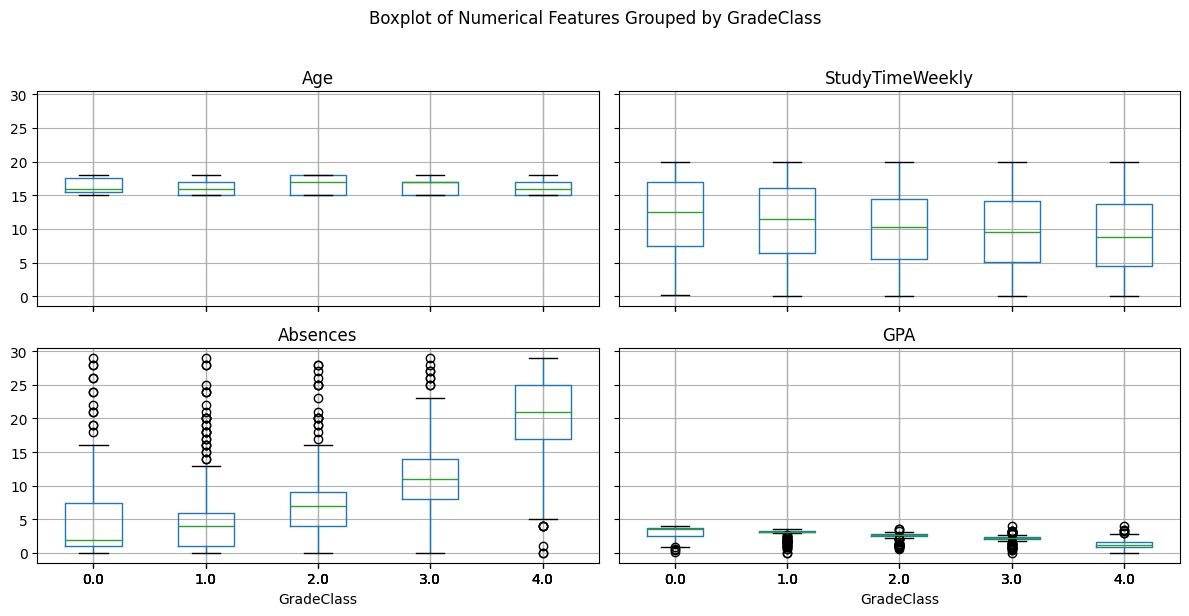

In [ ]:
df.boxplot(
    column=['Age', 'StudyTimeWeekly', 'Absences', 'GPA'],
    by='GradeClass',
    figsize=(12, 6),
)
plt.suptitle('Boxplot of Numerical Features Grouped by GradeClass', y=1.02)
plt.tight_layout()
plt.show()

The boxplots present the five-number summary and outlier detection for Age, StudyTimeWeekly, Absences, and GPA grouped by GradeClass. Distinct outliers are detected as data points extending beyond the whiskers in Absences (exceptionally high absence counts) and GPA (students with unusually low values), whereas Age and StudyTimeWeekly displays a consistent spread without extreme outliers. Because these data points operate on drastically different scales and the identified outliers can skew distance-based algorithms, outlier handling and feature scaling are required during preprocessing.

### Outliers

In [ ]:
from scipy.stats import zscore

numeric_cols = ['GPA', 'StudyTimeWeekly', 'Absences', 'Age']
threshold = 2

print('--- Outliers using Z-Score Method (Threshold = 2) ---')

for col in numeric_cols:
  z = abs(zscore(df[col]))
  outliers_count = (z > threshold).sum()

  print(f"Column '{col}': {outliers_count} outliers")

--- Outliers using Z-Score Method (Threshold = 2) ---
Column 'GPA': 46 outliers
Column 'StudyTimeWeekly': 0 outliers
Column 'Absences': 0 outliers
Column 'Age': 0 outliers


For outlier detection, the Z-score method was applied to the numerical features (Age, StudyTimeWeekly, Absences, and GPA) with a threshold of 2 ( ∣Z∣>2 ),this result differs from the visualizations observed in the Boxplots, as the boxplots rely on the Interquartile Range (IQR) method ( 1.5×IQR ) grouped by target classes (GradeClass). While the IQR visualizations highlight class-relative deviations, the Z-score approach was chosen here to detect global, multi-feature deviations across the entire dataset according to standard preprocessing practices.

### Histogram

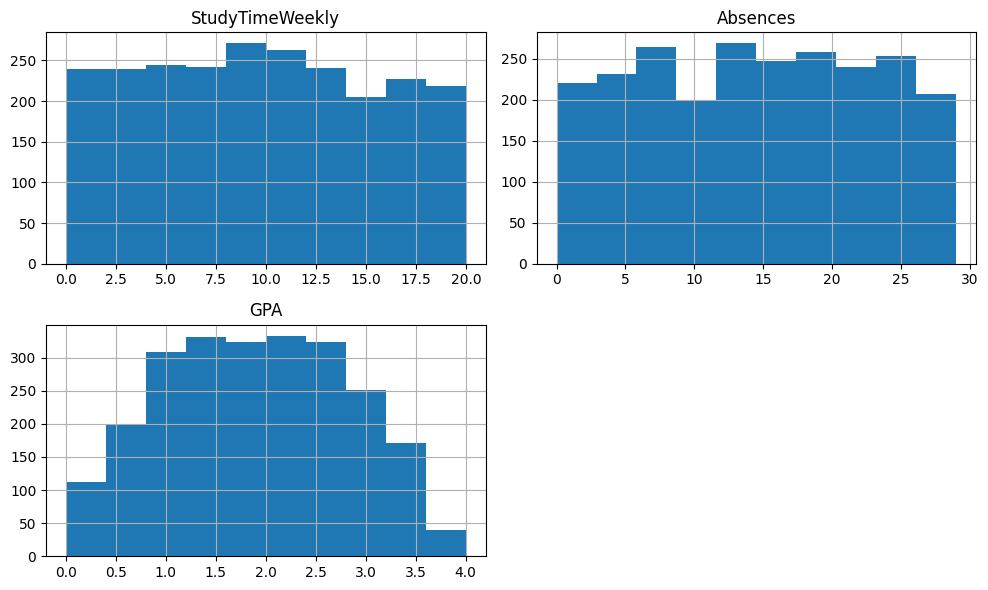

In [ ]:
df[['StudyTimeWeekly', 'Absences', 'GPA']].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

The histograms represent the frequency distribution of our continuous features. GPA displays a bell-shaped distribution centered between 1.5 and 2.5, representing typical academic achievement spreads. StudyTimeWeekly and Absences are spread evenly across students. The continuous nature and differing scale widths seen in these histograms justify applying normalization or discretization during preprocessing.

### Scatter Plot

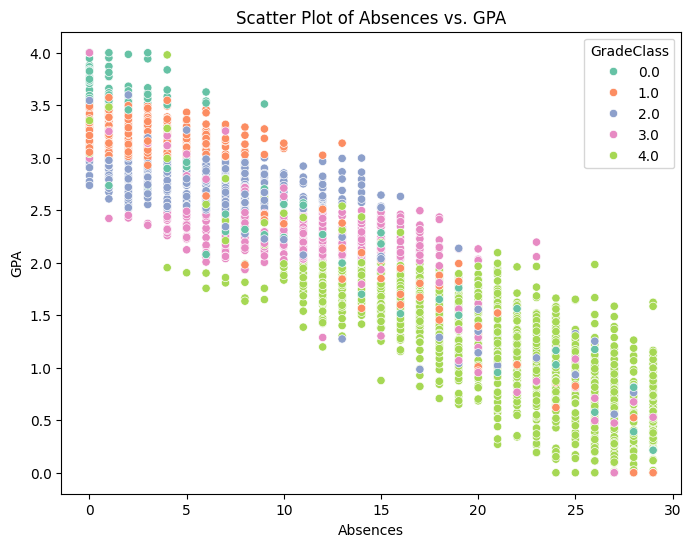

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Absences',
    y='GPA',
    data=df,
    hue='GradeClass',
    palette='Set2',
)
plt.title('Scatter Plot of Absences vs. GPA')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.show()

The scatter plot displays the pairwise relationship between Absences and GPA, with points colored by GradeClass. A strong negative linear pattern is evident: higher student absences correlate with lower GPA values and lower grade classes. This demonstrates that Absences carries substantial predictive power, confirming it should be retained for decision tree classification without dimensionality removal.

### Bar Plot

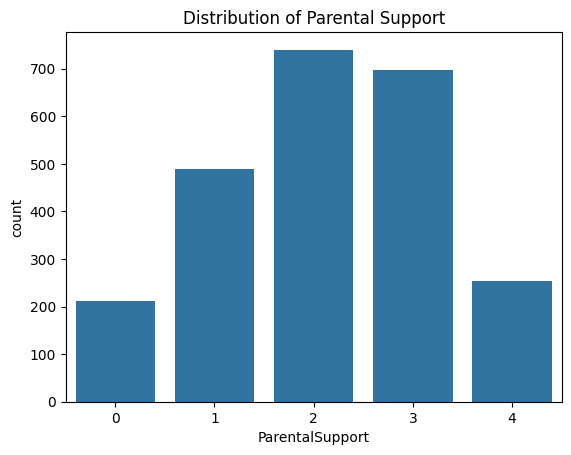

In [ ]:
sns.countplot(x='ParentalSupport', data=df)
plt.title('Distribution of Parental Support')
plt.show()

The bar chart shows the student counts across all categories of ParentalSupport. The categories are balanced with sufficient representation across every level (none to very high), confirming no servere category imbalance issues exist for this predictor that would require resampling during the preprocessing phase.

### Class Label Distribution

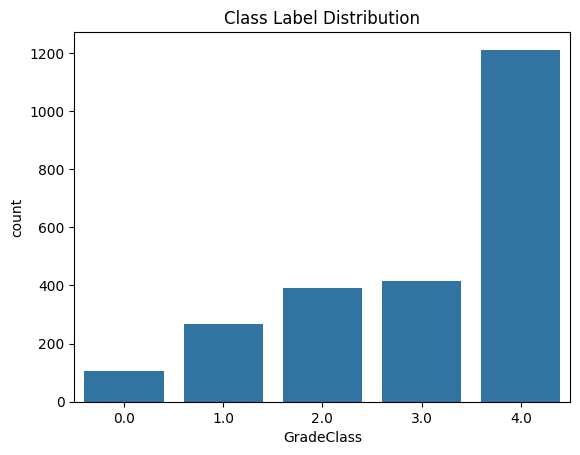

In [ ]:
sns.countplot(x='GradeClass', data=df)
plt.title("Class Label Distribution")
plt.show()

The class label distribution for ⁠GradeClass⁠ shows a noticeable class imbalance. Class 4.0 is the most frequent with over 1,200 samples, while class 0.0 has the lowest count around 100 samples. This imbalance suggests that resampling techniques may be considered during preprocessing to prevent model bias.



Based on the exploratory data analysis, the dataset has no missing values. However, the presence of numerical outliers and class imbalance in ⁠GradeClass⁠ indicates that preprocessing steps such as outlier handling, feature scaling/normalization will be necessary to improve model performance.

## Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from scipy.stats import zscore


In [ ]:
df_processed = df

print("Raw Dataset Snapshot")
display(df_processed.head())



Raw Dataset Snapshot


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


### Technique 1: Noise Removal(handling outliers using z-score)

Why it was applied (Justification): Exploratory Data Analysis (EDA) in Phase 1 identified potential extreme values in continuous numerical features. Removing unusual observations helps reduce their influence on data analysis and improves data quality before applying machine learning techniques.


How and on which attributes: The Z-score method was applied to continuous numerical attributes (StudyTimeWeekly, Absences, and GPA). Rows containing an absolute Z-score greater than or equal to 2 (|Z| > 2) in any of these attributes were filtered out.


Dataset Improvement: Successfully identified and removed extreme observations while retaining 2,346 student records. This reduces the influence of unusual values and helps improve data quality for subsequent analysis and model training.

In [ ]:
numeric_cols = ['StudyTimeWeekly', 'Absences', 'GPA']
z_scores = np.abs(zscore(df_processed[numeric_cols]))
df_processed = df_processed[(z_scores < 2).all(axis=1)]
print(f"\nDataset shape after Outlier Removal: {df_processed.shape}")


Dataset shape after Outlier Removal: (2346, 15)


### Technique 2: Discretization(binning)

Why it was applied (Justification): GPA is a continuous numerical feature. Discretization was applied to convert GPA values into three clear categories, making GPA levels easier to interpret and analyze.


How and on which attributes: The GPA attribute was divided into three intervals using pd.cut: Low (0) for values up to 2.0, Medium (1) for values greater than 2.0 and up to 3.0, and High (2) for values greater than 3.0. A new column, GPA_Level, was created while preserving the original GPA attribute.


Dataset Improvement: Converted continuous GPA values into three meaningful levels. The resulting distribution included 1,253 students in Low, 797 in Medium, and 269 in High. This makes GPA categories easier to interpret and compare while preserving the original numerical values for further analysis.

In [ ]:
bins = [-np.inf, 2.0, 3.0, np.inf]
labels = [0, 1, 2]
df_processed['GPA_Level'] = pd.cut(
    df_processed['GPA'],
    bins=bins,
    labels=labels,
    include_lowest=True
    ).astype(int)
print("Discretization applied successfully")
print("\nGPA Level Counts:")
print(df_processed['GPA_Level'].value_counts().sort_index())
display(df_processed[['GPA', 'GPA_Level']].head())

Discretization applied successfully

GPA Level Counts:
GPA_Level
0    1253
1     797
2     296
Name: count, dtype: int64


/tmp/ipykernel_1032/2862546156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['GPA_Level'] = pd.cut(


,GPA,GPA_Level
0,2.929196,1
1,3.042915,2
2,0.112602,0
3,2.054218,1
4,1.288061,0


### Technique 3: Normalization(Min-Max Normalization)


Why it was applied (Justification):
StudyTimeWeekly is a continuous numerical attribute. Min-Max Normalization was applied to transform its values into a standard range between 0 and 1, making the values easier to interpret and compare.

How and on which attributes:
MinMaxScaler was applied only to the StudyTimeWeekly attribute. Its values were transformed into the range [0, 1], while other attributes, including GPA and Absences, were left unchanged.

Dataset Improvement:
The transformation successfully rescaled StudyTimeWeekly values into the range [0, 1]. This provides a standardized representation of weekly study hours while preserving the relative order of the original values.

In [ ]:
scaler = MinMaxScaler()

df_processed['StudyTimeWeekly'] = scaler.fit_transform(
    df_processed[['StudyTimeWeekly']]
)

print("\n--- StudyTimeWeekly successfully normalized ---")

display(df_processed[['StudyTimeWeekly']].head())


--- StudyTimeWeekly successfully normalized ---


/tmp/ipykernel_1032/4049959779.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed['StudyTimeWeekly'] = scaler.fit_transform(


,StudyTimeWeekly
0,0.992773
1,0.771270
2,0.210718
3,0.501965
4,0.233840


RAW DATASET VS PROCESSED DATASET

In [ ]:
print("\nRaw Dataset (Before Preprocessing)")
display(df.head())

print("\nPreprocessed Dataset (After Preprocessing)")
display(df_processed.head())



Raw Dataset (Before Preprocessing)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0



Preprocessed Dataset (After Preprocessing)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,GPA_Level
0,1001,17,1,0,2,0.992773,7,1,2,0,0,1,0,2.929196,2.0,1
1,1002,18,0,0,1,0.771270,0,0,1,0,0,0,0,3.042915,1.0,2
2,1003,15,0,2,3,0.210718,26,0,2,0,0,0,0,0.112602,4.0,0
3,1004,17,1,0,3,0.501965,14,0,3,1,0,0,0,2.054218,3.0,1
4,1005,17,1,0,2,0.233840,17,1,3,0,0,0,0,1.288061,4.0,0


Save the preprocessed Data

In [ ]:
df_processed.to_csv('Preprocessed_dataset.csv', index=False)
print("\nSuccess: 'Preprocessed_dataset.csv' has been saved successfully!")




Success: 'Preprocessed_dataset.csv' has been saved successfully!
